## Settings & imports

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
import string
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
import csv
import pickle
import re

In [2]:
book_name = 'ml'

In [3]:
import json

with open('../config.json', 'r') as f:
    config = json.load(f)

which_dataset = config["which_dataset"]
preprocessing_method = config["preprocessing_method"] # normalization / logarithm
remove_outer_bool = config["remove_outer"]
how_many_outer_to_remove = config["how_many_outer_to_remove"]
elements_to_keep = config["elements_to_keep"][which_dataset]

data_path = config["data_path"][which_dataset]
target_path = config["target_path"][which_dataset]
figures_path = config["figures_path"]
models_path = config["models_path"][which_dataset]
classes_path = config["classes_path"]
Konstytucja_results_path = config["Konstytucja_results_path"][which_dataset]

## Loading the data & preprocessing

In [4]:
inks = np.loadtxt(Konstytucja_results_path, delimiter=',')
df = pd.DataFrame(data=inks, columns=elements_to_keep)
df.reset_index(drop=True, inplace=True)

In [5]:
classes_df = pd.read_excel(classes_path, header=1, usecols=['NAZWA', 'OPIS'])
classes_df['NAZWA_short'] = classes_df['NAZWA'].apply(lambda x: 
                                                    re.split(r'(\d+)', x)[0] + re.split(r'(\d+)', x)[1] if len(re.split(r'(\d+)', x))>1 else re.split(r'(\d+)', x)[0]
                                                   )                                                    
classes_df.drop_duplicates(['NAZWA', 'OPIS'], inplace=True)
classes_df_supp = classes_df.drop_duplicates(['NAZWA_short'])
classes_df_supp['NAZWA'] = classes_df['NAZWA_short']
classes_df = pd.concat([classes_df, classes_df_supp])
classes_df.drop_duplicates(inplace=True)
classes_df.reset_index(inplace=True, drop=True)

/tmp/ipykernel_6476/3014040627.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  classes_df_supp['NAZWA'] = classes_df['NAZWA_short']


In [6]:
def remove_outer(group, n):
    return group.iloc[n:-n] if len(group) > 2*n else pd.DataFrame(columns=group.columns)

In [7]:
########################################################
# check if joining is ok: especially labelss like APP15D and similar (if they have nans and if they should have nans)

In [8]:
if which_dataset == 'old':
    ground_truth_df = pd.read_csv(target_path, usecols=['probka', 'short'])
    ground_truth_df.rename(columns={"probka": "Sample_id"}, inplace=True)
elif which_dataset == 'new':
    ground_truth_df = pd.read_csv(target_path, usecols=['name'])
    ground_truth_df['Sample_id'] = ground_truth_df['name'].apply(lambda x: x.split('_')[0] if len(x.split('_'))==2 else x.split('_')[0] + x.split('_')[1])
    ground_truth_df['Sample_id'] = ground_truth_df['Sample_id'].apply(lambda x: x.replace('.', ''))
    ground_truth_df['short'] = ground_truth_df['Sample_id'].apply(lambda x: re.split(r'\d+', x)[0])
    ground_truth_df.drop(columns=['name'], inplace=True)

ground_truth_df.reset_index(drop=True, inplace=True)

if remove_outer_bool:
    ground_truth_df = ground_truth_df.groupby('Sample_id', group_keys=False).apply(remove_outer, n=how_many_outer_to_remove)

In [9]:
ground_truth_df = pd.merge(left=ground_truth_df, right=classes_df, how='left', left_on='Sample_id', right_on='NAZWA')

ground_truth_df['OPIS'] = ground_truth_df['OPIS'].apply(lambda x: str(x).strip())
ground_truth_df.drop(columns=['NAZWA', 'NAZWA_short'], inplace=True)
ground_truth_df.reset_index(drop=True, inplace=True)

In [10]:
# with pd.option_context('display.max_rows', None, 'display.max_columns', None):
#     print(ground_truth_df)

### Dividing to APP, ASC, ML

In [11]:
df_app = df[ground_truth_df['short'] == 'APP']
df_asc = df[ground_truth_df['short'] == 'ASC']
df_ml = df[ground_truth_df['short'] == 'ML']

if book_name == 'app':
    df = df_app
elif book_name == 'asc':
    df = df_asc
elif book_name == 'ml':
    df = df_ml
elif book_name == 'all':
    pass

### Removing some data

1. Let's keep only columns that we need.

To reduce the set of used elements run cell below. Then, instead of predicting 29 numbers, we will predict only 8. We will also use only 8 numbers as input.

In [12]:
df = df[elements_to_keep]

2. Let's check if there are any rows with missing values.

In [13]:
(df.shape[0] - df.dropna().shape[0])/df.shape[0]

0.0

### Converting to np.array

In [14]:
X = np.array(df.values)

### Normalizing / taking logarithm

In [15]:
def adjusted_log_transform(input_array):
    res = np.where(input_array>0, np.log(input_array), 0.)
    return res

In [16]:
if preprocessing_method == 'normalization':

    X = (X - np.min(X, axis=0))/np.std(X, axis=0)
    
elif preprocessing_method == 'logarithm':
    
    X = adjusted_log_transform(X)

elif preprocessing_method == 'logarithm_and_normalization':
    
    #logarithm
    X = adjusted_log_transform(X)
    
    #normalization
    X = (X - np.min(X, axis=0))/np.std(X, axis=0)
    
elif preprocessing_method == 'none':
    
    pass

/tmp/ipykernel_6476/2387706189.py:2: RuntimeWarning: invalid value encountered in log
  res = np.where(input_array>0, np.log(input_array), 0.)


### Ground truth

In [17]:
class_df_app = ground_truth_df[ground_truth_df['short'] == 'APP'][['Sample_id','OPIS']]
class_df_asc = ground_truth_df[ground_truth_df['short'] == 'ASC'][['Sample_id', 'OPIS']]
class_df_ml = ground_truth_df[ground_truth_df['short'] == 'ML'][['Sample_id', 'OPIS']]

if book_name == 'app':
    class_df = class_df_app
elif book_name == 'asc':
    class_df = class_df_asc
elif book_name == 'ml':
    class_df = class_df_ml
elif book_name == 'all':
    class_df = ground_truth_df[['Sample_id', 'OPIS']]

class_df.columns = ['Code', 'Class name']

In [18]:
y = class_df['Class name']
y = [str(y) for y in y]
class_df.reset_index(inplace=True, drop=True)

### PCA - all points

In [19]:
from sklearn.decomposition import PCA

n_components = 2
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X)

In [20]:
#%matplotlib widget

In [21]:
signatures = [word for word in set(y) if 'podpis' in word]
other = list(set(y).difference(set(signatures)))

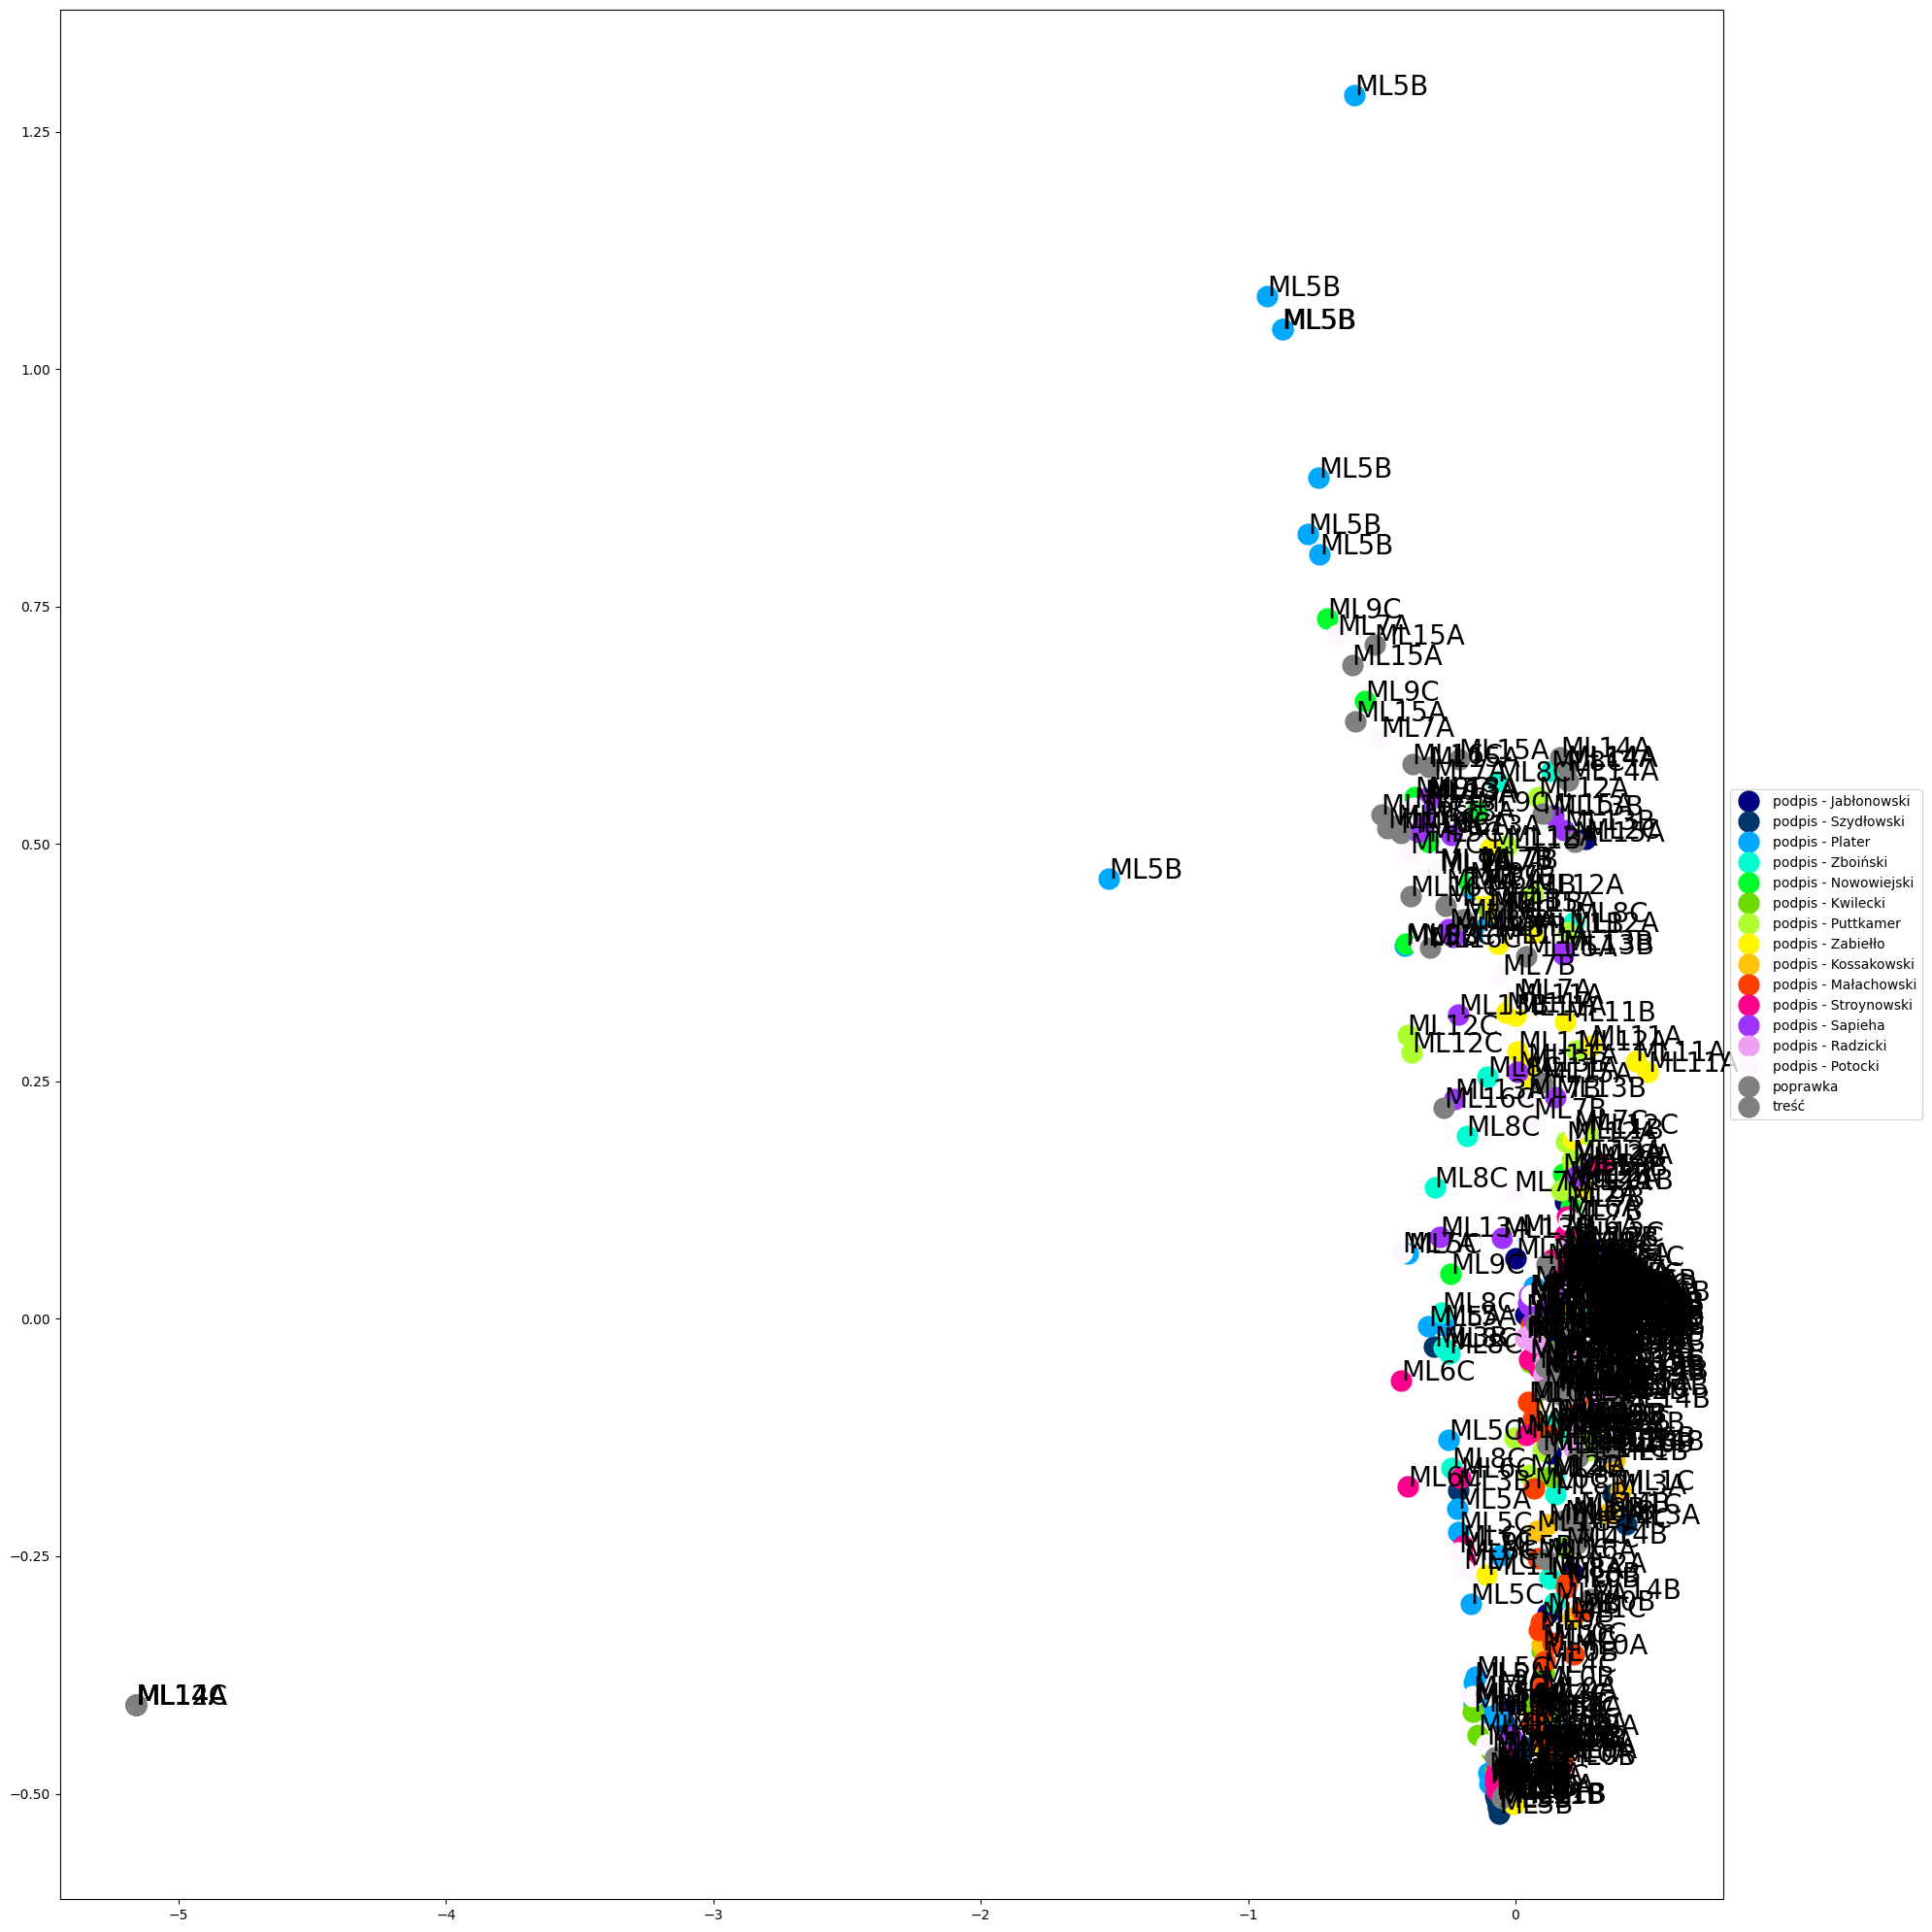

In [22]:
color = cm.gist_ncar(np.linspace(0, 1, len(signatures)))
grays = np.concatenate([np.array([0.5, 0.5, 0.5, 1]).reshape(1,-1) for _ in range(len(other))], axis=0)
color = np.concatenate([color, grays])
    
for label_nr, label in enumerate(signatures + other):
    x_pca_0 = [X_pca[i, 0] for i in range(X_pca.shape[0]) if y[i] == label]
    x_pca_1 = [X_pca[i,1] for i in range(X_pca.shape[0]) if y[i] == label]
    plt.plot(x_pca_0, x_pca_1, 'o',label = label, color=color[label_nr], markersize=15)
    
for i in range(X_pca.shape[0]):
    if isinstance(y[i], float):
        pass
    else:
        ann = class_df['Code'][i]
        plt.annotate(ann, (X_pca[i, 0], X_pca[i,1]), size=20)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.gcf().set_size_inches((20,20))
plt.tight_layout()
plt.savefig(figures_path + 'pca_' + book_name + '.png')

### PCA - means of classes

In [23]:
from sklearn.decomposition import PCA

n_components = 2
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X)

In [24]:
temp_df = class_df
temp_df['PC_0'] = X_pca[:,0]
temp_df['PC_1'] = X_pca[:,1]

means_df = class_df[['Code', 'Class name']].drop_duplicates()

In [25]:
for pc_nr in range(n_components):
    means_df['PC_' + str(pc_nr)] = temp_df.groupby('Code')['PC_' + str(pc_nr)].transform('mean')

In [26]:
X_pca_mean = means_df[['PC_' + str(nr) for nr in range(n_components)]].values
y_mean = list(means_df['Class name'])

In [27]:
#%matplotlib widget

In [28]:
signatures = [word for word in set(y_mean) if 'podpis' in word]
other = list(set(y_mean).difference(set(signatures)))

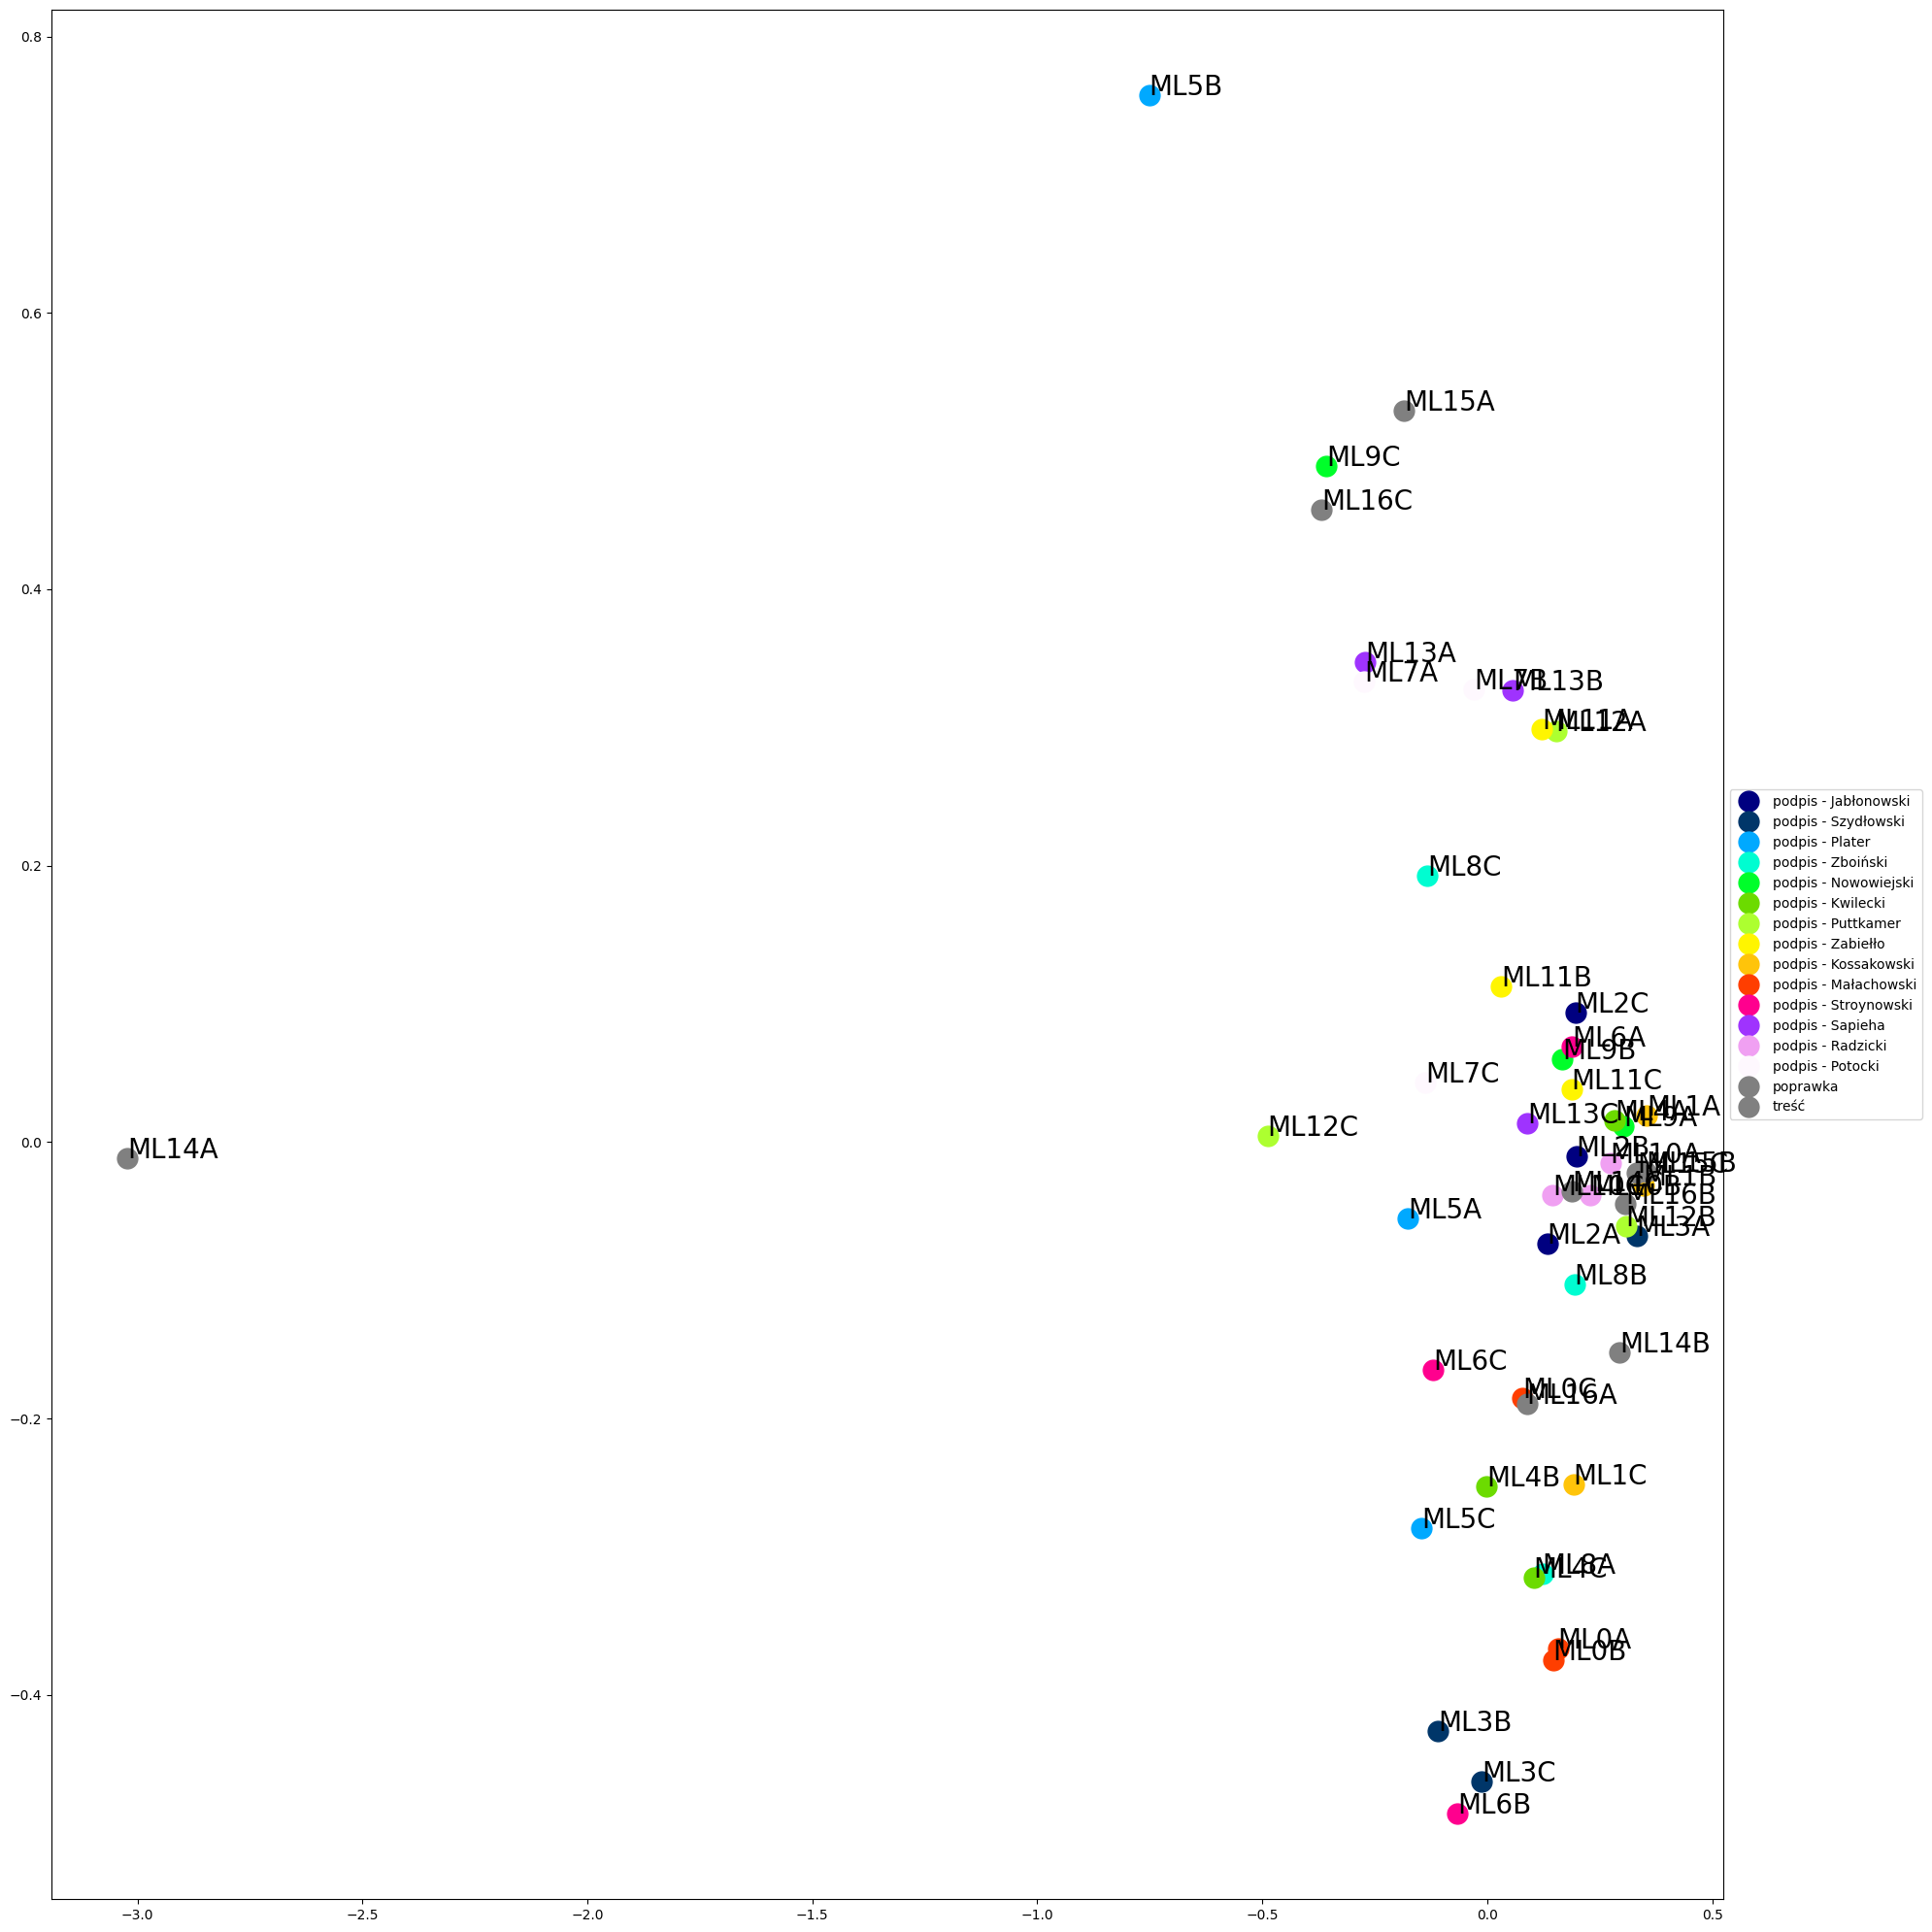

In [29]:
color = cm.gist_ncar(np.linspace(0, 1, len(signatures)))
grays = np.concatenate([np.array([0.5, 0.5, 0.5, 1]).reshape(1,-1) for _ in range(len(other))], axis=0)
color = np.concatenate([color, grays])
    
for label_nr, label in enumerate(signatures + other):
    x_pca_0 = [X_pca_mean[i, 0] for i in range(X_pca_mean.shape[0]) if y_mean[i] == label]
    x_pca_1 = [X_pca_mean[i,1] for i in range(X_pca_mean.shape[0]) if y_mean[i] == label]
    plt.plot(x_pca_0, x_pca_1, 'o',label = label, color=color[label_nr], markersize=15)
    
for i in range(X_pca_mean.shape[0]):
    if isinstance(y_mean[i], float):
        pass
    else:
        ann = means_df['Code'].iloc[i]
        plt.annotate(ann, (X_pca_mean[i, 0], X_pca_mean[i,1]), size=20)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.gcf().set_size_inches((20,20))
plt.tight_layout()
plt.savefig(figures_path + 'pca_' + book_name + '_means.png')

### PCA - representatives

### tSNE - all points

In [30]:
from sklearn.manifold import TSNE

n_components = 2
tsne = TSNE(n_components=n_components, random_state=42)
X_tsne = tsne.fit_transform(X)

In [31]:
#%matplotlib widget

In [32]:
signatures = [word for word in set(y) if 'podpis' in word]
other = list(set(y).difference(set(signatures)))

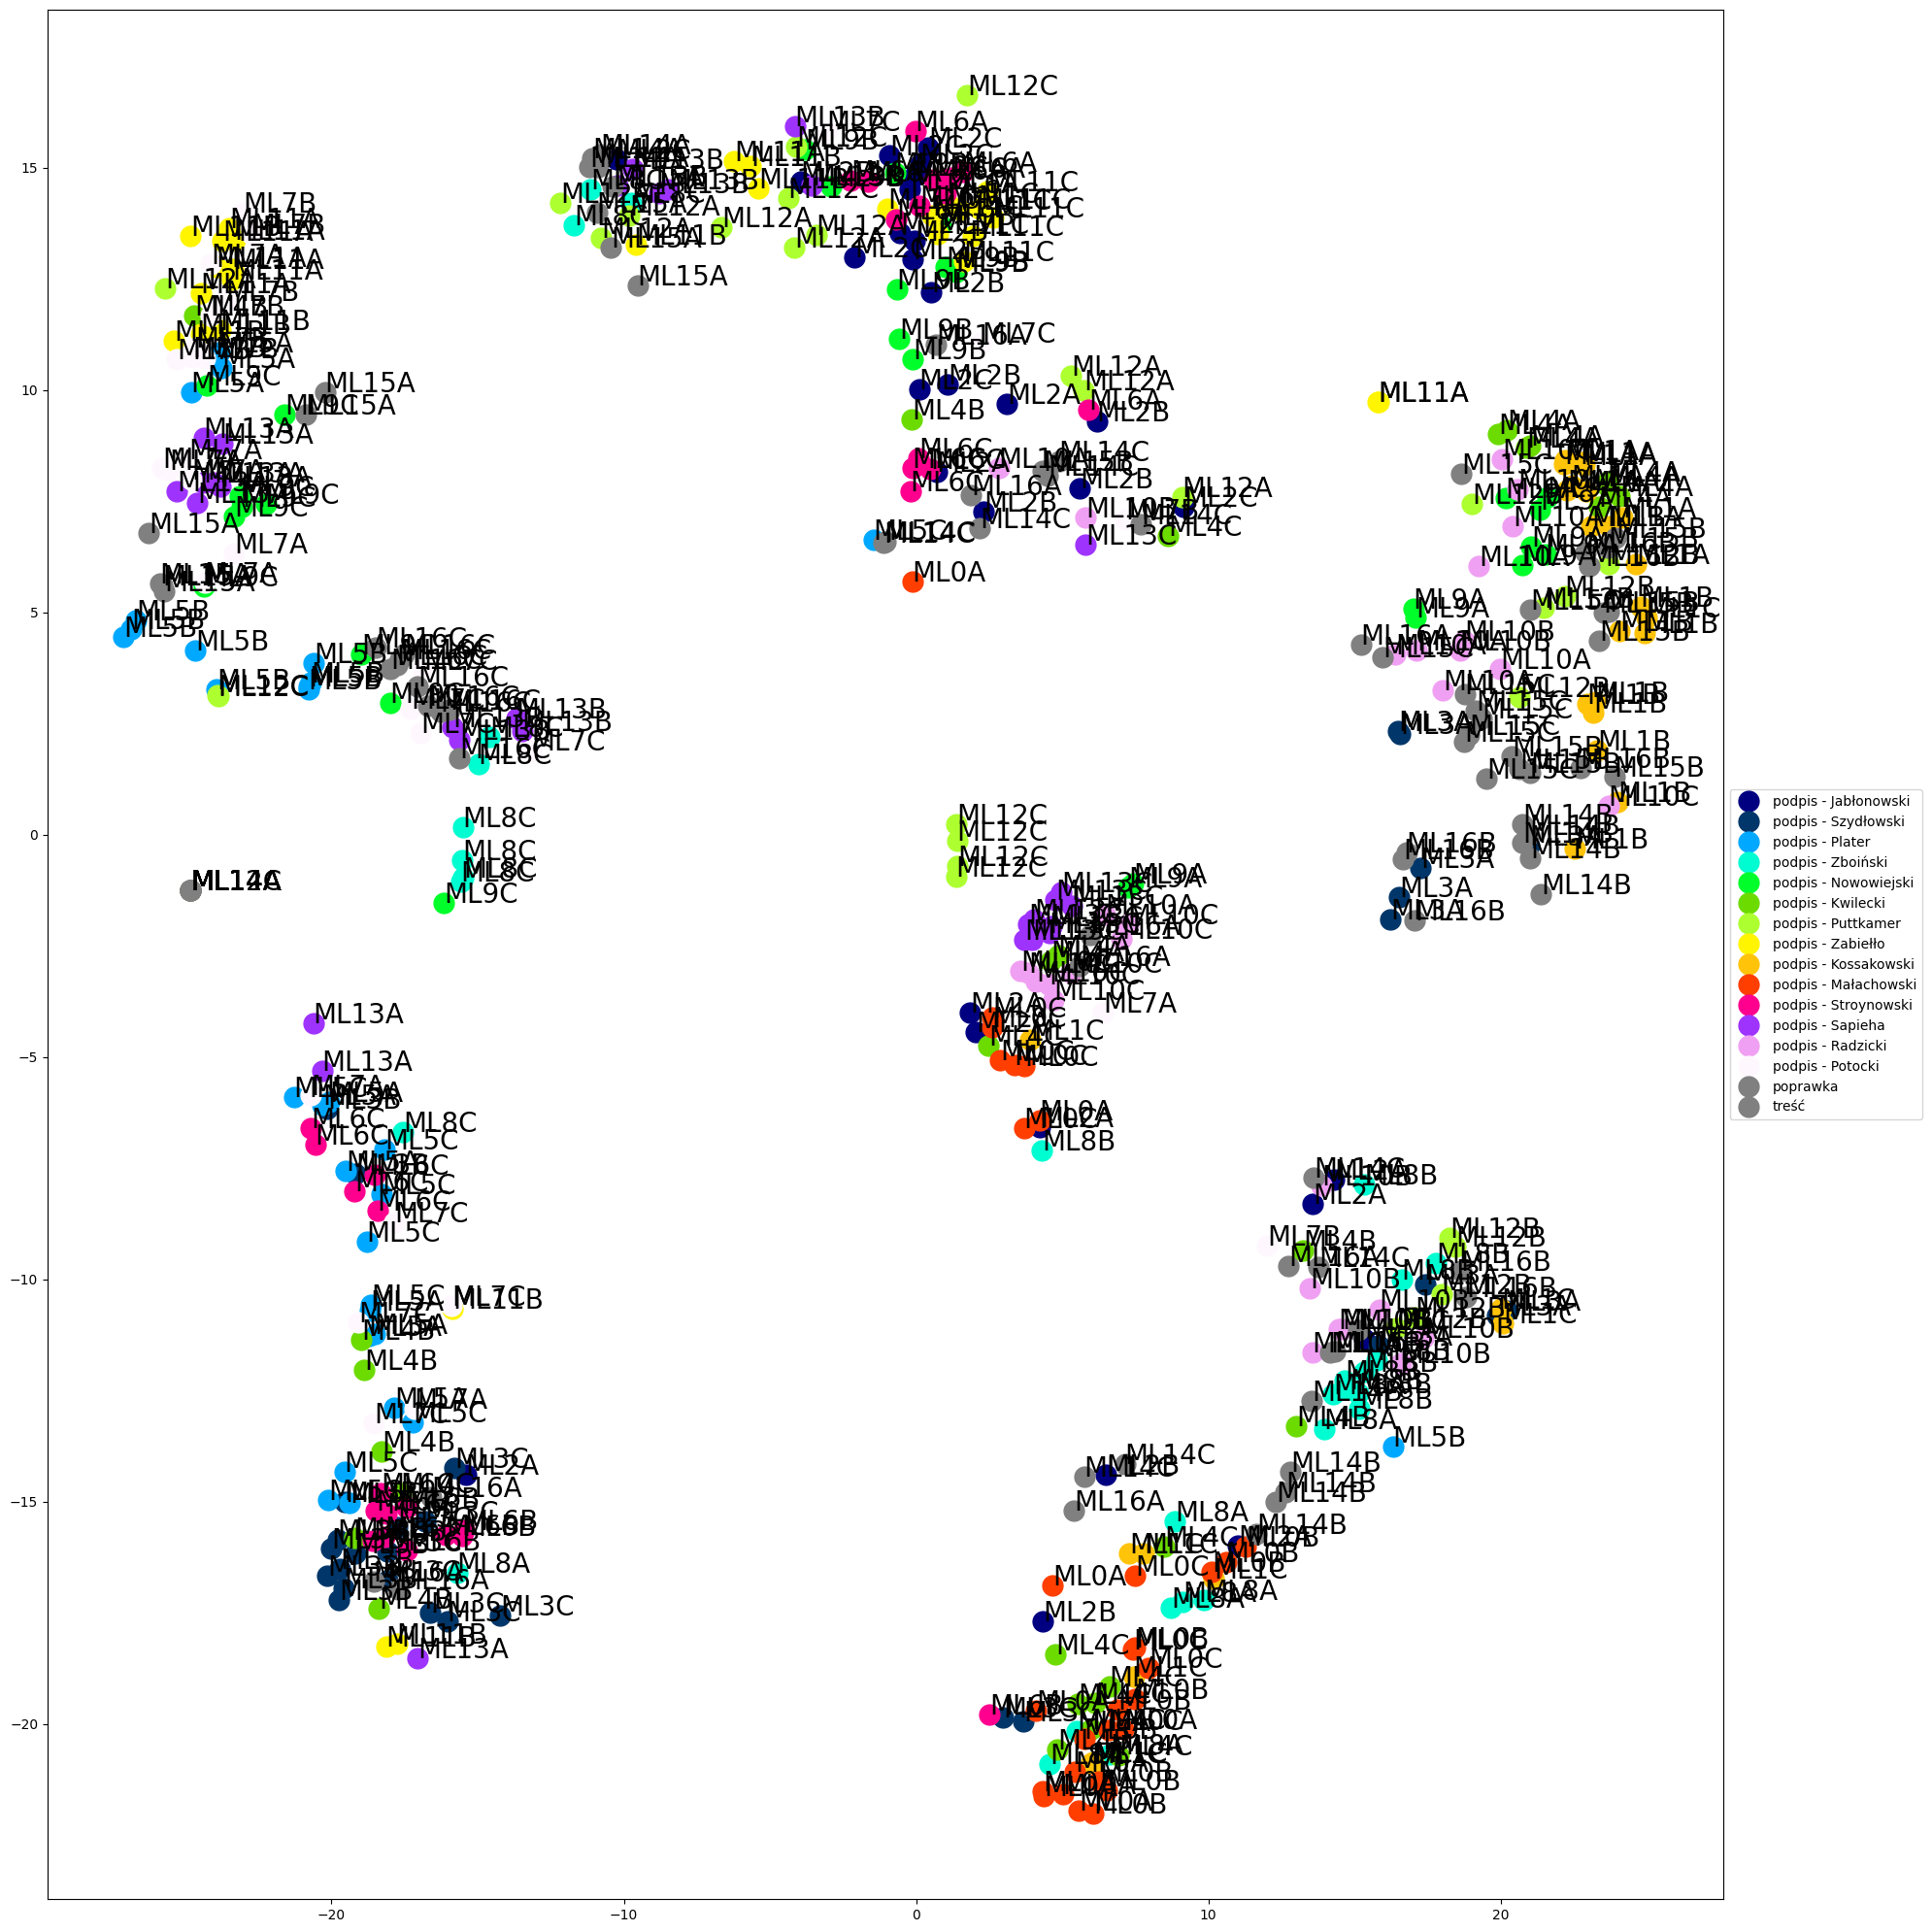

In [33]:
color = cm.gist_ncar(np.linspace(0, 1, len(signatures)))
grays = np.concatenate([np.array([0.5, 0.5, 0.5, 1]).reshape(1,-1) for _ in range(len(other))], axis=0)
color = np.concatenate([color, grays])
    
for label_nr, label in enumerate(signatures + other):
    x_tsne_0 = [X_tsne[i, 0] for i in range(X_tsne.shape[0]) if y[i] == label]
    x_tsne_1 = [X_tsne[i, 1] for i in range(X_tsne.shape[0]) if y[i] == label]
    plt.plot(x_tsne_0, x_tsne_1, 'o',label = label, color=color[label_nr], markersize=15)
    
for i in range(X_tsne.shape[0]):
    if isinstance(y[i], float):
        pass
    else:
        ann = class_df['Code'][i]
        plt.annotate(ann, (X_tsne[i, 0], X_tsne[i,1]), fontsize=20)
        
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.gcf().set_size_inches((20,20))
plt.tight_layout()
plt.savefig(figures_path + 'tsne_' + book_name + '.png')

- drawing random records from the same group?

### tSNE - means of classes

In [34]:
from sklearn.manifold import TSNE

n_components = 2
tsne = TSNE(n_components=n_components, random_state=42)
X_tsne = tsne.fit_transform(X)

In [35]:
temp_df = class_df
temp_df['tSNE_dim_0'] = X_tsne[:,0]
temp_df['tSNE_dim_1'] = X_tsne[:,1]

means_df = class_df[['Code', 'Class name']].drop_duplicates()

In [36]:
for tsne_nr in range(n_components):
    means_df['tSNE_dim_' + str(tsne_nr)] = temp_df.groupby('Code')['tSNE_dim_' + str(tsne_nr)].transform('mean')

In [37]:
X_tsne_mean = means_df[['tSNE_dim_' + str(nr) for nr in range(n_components)]].values
y_mean = list(means_df['Class name'])

In [38]:
signatures = [word for word in set(y_mean) if 'podpis' in word]
other = list(set(y_mean).difference(set(signatures)))

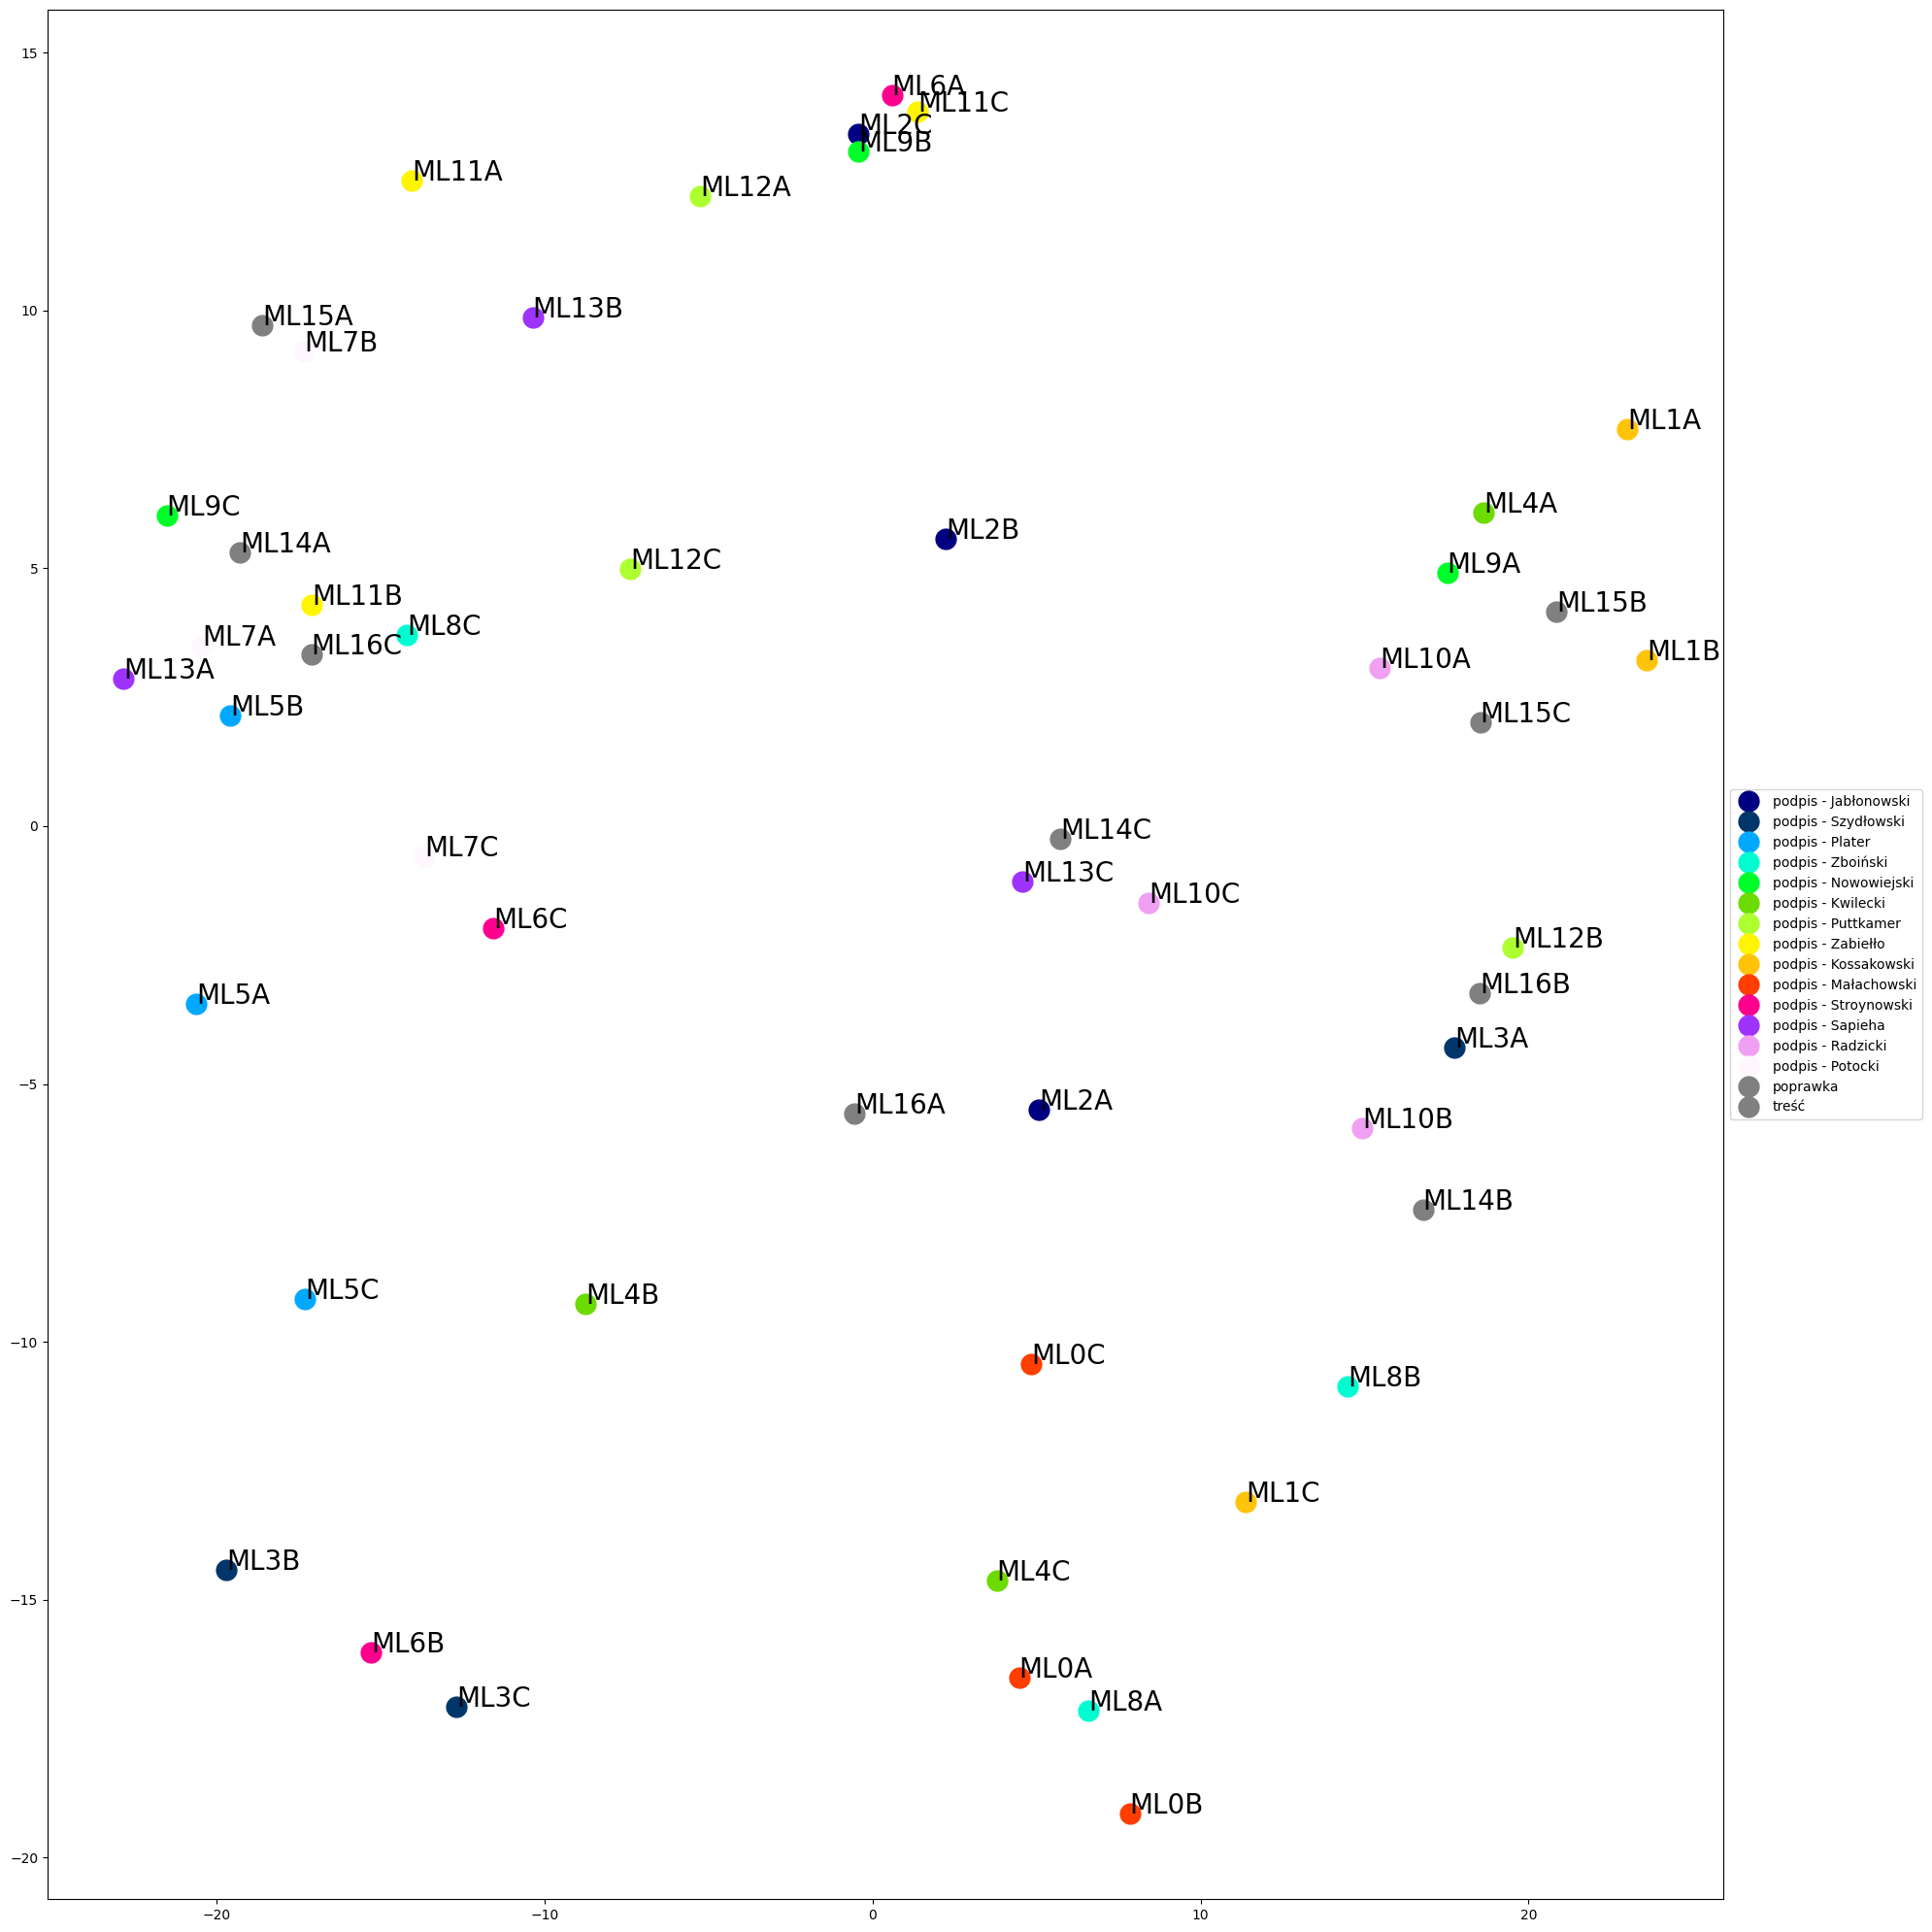

In [39]:
color = cm.gist_ncar(np.linspace(0, 1, len(signatures)))
grays = np.concatenate([np.array([0.5, 0.5, 0.5, 1]).reshape(1,-1) for _ in range(len(other))], axis=0)
color = np.concatenate([color, grays])
    
for label_nr, label in enumerate(signatures + other):
    x_tsne_0 = [X_tsne_mean[i, 0] for i in range(X_tsne_mean.shape[0]) if y_mean[i] == label]
    x_tsne_1 = [X_tsne_mean[i,1] for i in range(X_tsne_mean.shape[0]) if y_mean[i] == label]
    plt.plot(x_tsne_0, x_tsne_1, 'o',label = label, color=color[label_nr], markersize=15)
    
for i in range(X_tsne_mean.shape[0]):
    if isinstance(y_mean[i], float):
        pass
    else:
        ann = means_df['Code'].iloc[i]
        plt.annotate(ann, (X_tsne_mean[i, 0], X_tsne_mean[i,1]), size=20)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.gcf().set_size_inches((20,20))
plt.tight_layout()
plt.savefig(figures_path + 'tsne_' + book_name + '_means.png')

In [40]:
################################################

## Clustering

In [ ]:
from sklearn import cluster

In [ ]:
y = class_df['Class name']
y = [str(y) for y in y]

In [ ]:
# if collapse:
#     y = [class_df['Class name'].iloc[13*i] for i in range(int(X.shape[0]))]
#     y = [str(y) for y in y]
# else:
#     y = class_df['Class name']
#     y = [str(y) for y in y]

In [ ]:
cluster_only_names = False
if cluster_only_names:
    X_to_cluster = X[names_indices,:]
    y_to_plot = [y[ind] for ind in names_indices]
else:
    X_to_cluster = X
    y_to_plot = y

In [ ]:
nr_of_clusters = 20
clustering = cluster.AgglomerativeClustering(n_clusters=nr_of_clusters).fit(X_to_cluster)
#clustering = cluster.SpectralClustering(n_clusters=nr_of_clusters).fit(X_to_cluster)
#clustering = cluster.DBSCAN().fit(X_to_cluster)

#clustering.labels_

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_to_cluster)

from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_to_cluster)

In [ ]:
#%matplotlib notebook

In [ ]:
annotate = True

unidentified = ['komentarz', 'nan', 'oblatowanie', 'papier', 'poprawka', 'treść']
names_set = set(y_to_plot).difference(set(unidentified))

color = cm.nipy_spectral(np.linspace(1, 0, len(names_set)))
    
for label_nr, label in enumerate(list(names_set) + list(unidentified)):
    if label in unidentified:
        x_pca_0 = [X_pca[i, 0] for i in range(X_pca.shape[0]) if y_to_plot[i] == label]
        x_pca_1 = [X_pca[i,1] for i in range(X_pca.shape[0]) if y_to_plot[i] == label]
        plt.plot(x_pca_0, x_pca_1, 'o', label = label, color='lightsteelblue')
    else:
        x_pca_0 = [X_pca[i, 0] for i in range(X_pca.shape[0]) if y_to_plot[i] == label]
        x_pca_1 = [X_pca[i,1] for i in range(X_pca.shape[0]) if y_to_plot[i] == label]
        plt.plot(x_pca_0, x_pca_1, 'o', label = label, color=color[label_nr])
    
if annotate:
    for i in range(X_pca.shape[0]):
        if isinstance(y_to_plot[i], float):
            pass
        else:
            #version with cluster numbers
            plt.annotate(clustering.labels_[i], (X_pca[i, 0], X_pca[i,1]))
            #version with book name
            #plt.annotate(class_df['Code'][i], (X_pca[i, 0], X_pca[i,1]))
        
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.rcParams['figure.figsize'] = [10, 7]

plt.tight_layout()
plt.show()

#plt.savefig('../figures/clustering_PCA_book_' + str(book_name) + '_annotate_' + str(annotate))

#PREDICTION ALL 13

In [ ]:
annotate = True

unidentified = ['komentarz', 'nan', 'oblatowanie', 'papier', 'poprawka', 'treść']
names_set = set(y_to_plot).difference(set(unidentified))

color = cm.nipy_spectral(np.linspace(1, 0, len(names_set)))
    
for label_nr, label in enumerate(list(names_set) + list(unidentified)):
    if label in unidentified:
        x_tsne_0 = [X_tsne[i, 0] for i in range(X_tsne.shape[0]) if y_to_plot[i] == label]
        x_tsne_1 = [X_tsne[i,1] for i in range(X_tsne.shape[0]) if y_to_plot[i] == label]
        plt.plot(x_tsne_0, x_tsne_1, 'o', label = label, color='lightsteelblue')
#     elif label in ['nan']:
#         pass
    else:
        x_tsne_0 = [X_tsne[i, 0] for i in range(X_tsne.shape[0]) if y_to_plot[i] == label]
        x_tsne_1 = [X_tsne[i,1] for i in range(X_tsne.shape[0]) if y_to_plot[i] == label]
        plt.plot(x_tsne_0, x_tsne_1, 'o', label = label, color=color[label_nr])
    
if annotate:
    for i in range(X_tsne.shape[0]):
        if isinstance(y_to_plot[i], float):
            pass
        else:
            plt.annotate(clustering.labels_[i], (X_tsne[i, 0], X_tsne[i,1]))
            
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.rcParams['figure.figsize'] = [10, 7]

plt.xlabel('tSNE dim 1')
plt.ylabel('tSNE dim 2')
plt.title('Constitution of 3 May')

plt.tight_layout()
plt.show()

#plt.savefig('../figures/clustering_tSNE_book_' + str(book_name) + '_annotate_' + str(annotate))

#PREDICTION ALL 13

In [ ]:
clusters = []
for i in range(nr_of_clusters):
    clust = [(int(el1), el2) for el1, el2 in list(zip(clustering.labels_, y_to_plot)) if el1==i]
    clusters.append(clust)

In [ ]:
clusters

In [ ]:
# with open(Konstytucja_results_path[object_name] + 'clustering_of_predicted_inks_nr_of_clusters' + str(nr_of_clusters) + '.pkl', 'wb') as f:
#     pickle.dump(clusters, f)

In [ ]:
ms = cluster.MeanShift(banwidth=banwidth, bin_seeding=True)
two_means = cluster.MiniBatchKMeans(
    n_clusters=params["n_clusters"],
    random_state=params["random_state"],
)
ward = cluster.AgglomerativeClustering(
    n_clusters=params["n_clusters"], linkage="ward", connectivity=connectivity
)
spectral = cluster.SpectralClustering(
    n_clusters=params["n_clusters"],
    eigen_solver="arpack",
    affinity="nearest_neighbors",
    random_state=params["random_state"],
)
dbscan = cluster.DBSCAN(eps=params["eps"])
hdbscan = cluster.HDBSCAN(
    min_samples=params["hdbscan_min_samples"],
    min_cluster_size=params["hdbscan_min_cluster_size"],
    allow_single_cluster=params["allow_single_cluster"],
)
optics = cluster.OPTICS(
    min_samples=params["min_samples"],
    xi=params["xi"],
    min_cluster_size=params["min_cluster_size"],
)
affinity_propagation = cluster.AffinityPropagation(
    damping=params["damping"],
    preference=params["preference"],
    random_state=params["random_state"],
)
average_linkage = cluster.AgglomerativeClustering(
    linkage="average",
    metric="cityblock",
    n_clusters=params["n_clusters"],
    connectivity=connectivity,
)
birch = cluster.Birch(n_clusters=params["n_clusters"])
gmm = mixture.GaussianMixture(
    n_components=params["n_clusters"],
    covariance_type="full",
    random_state=params["random_state"],
)

clustering_algorithms = (
    ("MiniBatch\nKMeans", two_means),
    ("Affinity\nPropagation", affinity_propagation),
    ("MeanShift", ms),
    ("Spectral\nClustering", spectral),
    ("Ward", ward),
    ("Agglomerative\nClustering", average_linkage),
    ("DBSCAN", dbscan),
    ("HDBSCAN", hdbscan),
    ("OPTICS", optics),
    ("BIRCH", birch),
    ("Gaussian\nMixture", gmm),
)